In [2]:
import os
from contextlib import redirect_stdout
from enum import Enum
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.text as mtext
import numpy as np
import utide as ut
import xarray as xr
from IPython.display import HTML
from matplotlib.figure import Figure
from numpy.typing import NDArray
from tqdm import tqdm


class IncludeSNR(Enum):
    """Enum for signal-to-noise ratio boolean plotting flags."""

    YES = True
    NO = False


HTML("""
    <style>
    .cell-output-ipywidget-background{background: transparent !important;}
    .widget-label{color: white !important;}
    </style>
""")

In [3]:
NOTEBOOK_DIR = Path().cwd().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
VEL_PATH_V1 = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise.nc"
)
VEL_PATH_V5 = (
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise_v5.nc"
)

GLOBEC_TIME = slice(np.datetime64("1997-01-01"), np.datetime64("2004-12-31"))
NANOOS_TIME = slice(np.datetime64("2006-07-01"), np.datetime64("2014-09-30"))
OOI_TIME = slice(np.datetime64("2015-04-01"), None)

In [4]:
def fit_utide(u: xr.DataArray, v: xr.DataArray) -> dict:
    """Fit a T-Tide model to the given u and v components.

    Returns:
        dict: A dictionary containing the tidal constituents and their parameters.

    """
    # don't need to print the output of utide, so redirect stdout to devnull
    with (
        Path(os.devnull).open("w", encoding="utf-8") as devnull,
        redirect_stdout(devnull),
    ):
        # just save the dict output of utide
        coef = ut.solve(
            u["time"],
            u,
            v,
            lat=44.64,
            method="ols",
            conf_int="linear",
        )

    return coef


def fit_utide_from_ds(
    ds: xr.Dataset,
) -> xr.Dataset:
    """Fit tidal constituents from a dataset containing u and v components.

    Args:
        ds (xr.Dataset): A dataset containing the u and v components of velocity,
            with a 'depth' dimension.

    Returns:
        xr.Dataset: A dataset containing the fitted tidal constituents and their parameters.

    """
    ds_list: list[xr.Dataset] = []
    for depth in tqdm(ds["depth"], desc="Fitting UTide"):
        # skip depths where either u or v is all NaN
        if np.all(np.isnan(ds["u"].sel(depth=depth))) or np.all(
            np.isnan(ds["v"].sel(depth=depth))
        ):
            continue

        # run utide to fit the tidal constituents for a given depth
        out = fit_utide(
            ds["u"].sel(depth=depth),
            ds["v"].sel(depth=depth),
        )

        # convert the output to a dataset
        out["name"] = [name.strip() for name in out["name"]]
        out_ds = xr.Dataset(
            {
                "freq": (["constituent"], out["aux"]["frq"]),
                "snr": (["constituent"], out["diagn"]["SNR"]),
                "pe": (["constituent"], out["diagn"]["PE"]),
                "major": (["constituent"], out["Lsmaj"]),
                "major_ci": (["constituent"], out["Lsmaj_ci"]),
                "minor": (["constituent"], out["Lsmin"]),
                "minor_ci": (["constituent"], out["Lsmin_ci"]),
                "inclination": (["constituent"], out["theta"]),
                "inclination_ci": (["constituent"], out["theta_ci"]),
                "phase": (["constituent"], out["Lsmaj"]),
                "phase_ci": (["constituent"], out["Lsmaj_ci"]),
            },
            coords={
                "time": ds.time,
                "constituent": out["name"],
            },
        )
        out_ds["u_mean"] = ([], out["umean"])
        out_ds["v_mean"] = ([], out["vmean"])
        out_ds["u_slope"] = ([], out["uslope"])
        out_ds["v_slope"] = ([], out["vslope"])
        out_ds = out_ds.expand_dims({"depth": [depth.values.astype(int)]}, axis=0)
        ds_list.append(out_ds)

    # combine the list of datasets along the depth dimension
    tide_out = xr.concat(ds_list, dim="depth")
    tide_out.attrs = {
        "description": "tidal constituents from UTide https://www.po.gso.uri.edu/~codiga/utide/utide.htm",
    }

    return tide_out


def plot_tidal_constituents(
    tide_ds: xr.Dataset,
    constituent: str,
    fig: Figure | None = None,
    snr: IncludeSNR = IncludeSNR.YES,
    **kwargs,
) -> tuple[Figure, NDArray]:
    """Plot the tidal constituents from a T-Tide output dataset.

    Args:
        tide_ds (xr.Dataset): A dataset containing the tidal constituents and their parameters, produced by `fit_utide_from_ds`.
        constituent (str): The name of the tidal constituent to plot.
        fig (Figure, optional): A matplotlib figure to plot on. If None, a new figure is created.
        snr (bool, optional): Whether to include the signal-to-noise ratio in the plot. Defaults to True.
        **kwargs: Additional keyword arguments to pass to the plotting functions.

    Returns:
        tuple[Figure, NDArray]: A tuple containing the figure and axes of the plot.

    """
    if fig is None:
        if snr:
            fig, axs = plt.subplots(1, 5, figsize=(12, 6))
        else:
            fig, axs = plt.subplots(1, 4, figsize=(10, 6))
    else:
        axs = fig.get_axes()
    axs[0].plot(tide_ds["major"], -tide_ds["depth"], label=constituent, **kwargs)
    axs[0].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["major"] - tide_ds["major_ci"],
        tide_ds["major"] + tide_ds["major_ci"],
        alpha=0.3,
    )
    axs[1].plot(tide_ds["minor"], -tide_ds["depth"], label=constituent, **kwargs)
    axs[1].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["minor"] - tide_ds["minor_ci"],
        tide_ds["minor"] + tide_ds["minor_ci"],
        alpha=0.3,
    )
    axs[2].plot(tide_ds["inclination"], -tide_ds["depth"], label=constituent, **kwargs)
    axs[2].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["inclination"] - tide_ds["inclination_ci"],
        tide_ds["inclination"] + tide_ds["inclination_ci"],
        alpha=0.3,
    )
    axs[3].plot(tide_ds["phase"], -tide_ds["depth"], label=constituent, **kwargs)
    axs[3].fill_betweenx(
        -tide_ds["depth"],
        tide_ds["phase"] - tide_ds["phase_ci"],
        tide_ds["phase"] + tide_ds["phase_ci"],
        alpha=0.3,
    )
    axs[0].set_xlabel("Major Axis [$\\mathsf{cm \\; s^{-1}}$]")
    axs[1].set_xlabel("Minor Axis [$\\mathsf{cm \\; s^{-1}}$]")
    axs[2].set_xlabel("Inclination [degrees]")
    axs[3].set_xlabel("Phase [degrees]")
    if snr:
        axs[4].plot(tide_ds["snr"], -tide_ds["depth"], label=constituent, **kwargs)
        axs[4].set_xscale("log")
        axs[4].axvline(2, color="k", linestyle="--")
        axs[4].set_xlabel("Signal-to-Noise Ratio")
    return fig, axs

In [5]:
velocity_v1 = xr.open_dataset(VEL_PATH_V1).resample(time="1h").mean()
velocity_v5 = xr.open_dataset(VEL_PATH_V5).resample(time="1h").mean()

velocity_v1_nanoos = velocity_v1.sel(time=NANOOS_TIME)
velocity_v5_nanoos = velocity_v5.sel(time=NANOOS_TIME)
velocity_v1_ooi = velocity_v1.sel(time=OOI_TIME)
velocity_v5_ooi = velocity_v5.sel(time=OOI_TIME)

In [6]:
tide_v1_nanoos = fit_utide_from_ds(velocity_v1_nanoos)
tide_v5_nanoos = fit_utide_from_ds(velocity_v5_nanoos)
tide_v1_ooi = fit_utide_from_ds(velocity_v1_ooi)
tide_v5_ooi = fit_utide_from_ds(velocity_v5_ooi)

Fitting UTide: 100%|██████████| 41/41 [01:51<00:00,  2.73s/it]


In [7]:
class LegendTitle:
    """Used to create subtitles in MatPlotLib legends.

    Use with plt.legend(handles, labels, handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)})
    """

    def __init__(self, text_props=None, width=None) -> None:
        self.text_props = text_props or {}
        self.width = width or None
        super().__init__()

    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        title = mtext.Text(
            x0,
            y0,
            f"\\underline{{\\textbf{{{orig_handle}}}}}",
            usetex=True,
            **self.text_props,
        )
        handlebox.add_artist(title)
        if self.width is not None:
            handlebox.width = self.width
        return title

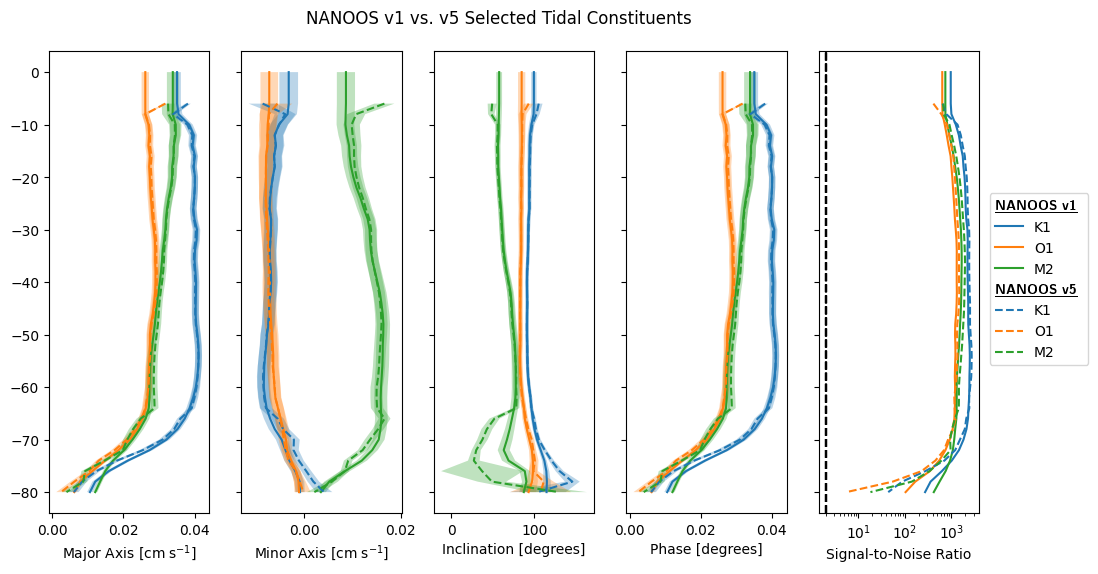

In [8]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)
constituents = ["K1", "O1", "M2"]
for const in constituents:
    tide = tide_v1_nanoos.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = tide_v5_nanoos.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="--")
handles, labels = axs[0].get_legend_handles_labels()
proxy = mpatches.FancyBboxPatch(
    xy=(0, 0), width=0, height=0, visible=False, mutation_aspect=0
)
handles.append("NANOOS v1")
labels.append("")
handles.append("NANOOS v5")
labels.append("")
order = [6, 0, 1, 2, 7, 3, 4, 5]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
leg = fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)
fig.suptitle("NANOOS v1 vs. v5 Selected Tidal Constituents", fontsize=12, y=0.95)
plt.savefig(
    FIGURES_DIR / "ttide_velocity_nanoos_v1_v5.png", dpi=300, bbox_inches="tight"
)

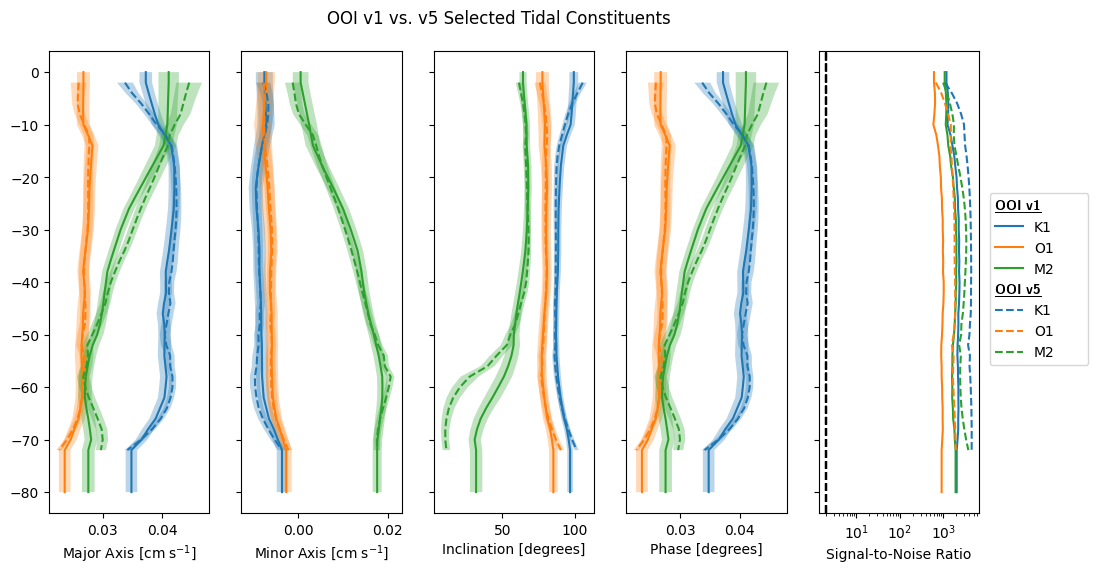

In [9]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)
constituents = ["K1", "O1", "M2"]
for const in constituents:
    tide = tide_v1_ooi.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = tide_v5_ooi.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="--")
handles, labels = axs[0].get_legend_handles_labels()
proxy = mpatches.FancyBboxPatch(
    xy=(0, 0), width=0, height=0, visible=False, mutation_aspect=0
)
handles.append("OOI v1")
labels.append("")
handles.append("OOI v5")
labels.append("")
order = [6, 0, 1, 2, 7, 3, 4, 5]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
leg = fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)
fig.suptitle("OOI v1 vs. v5 Selected Tidal Constituents", fontsize=12, y=0.95)
plt.savefig(FIGURES_DIR / "ttide_velocity_ooi_v1_v5.png", dpi=300, bbox_inches="tight")

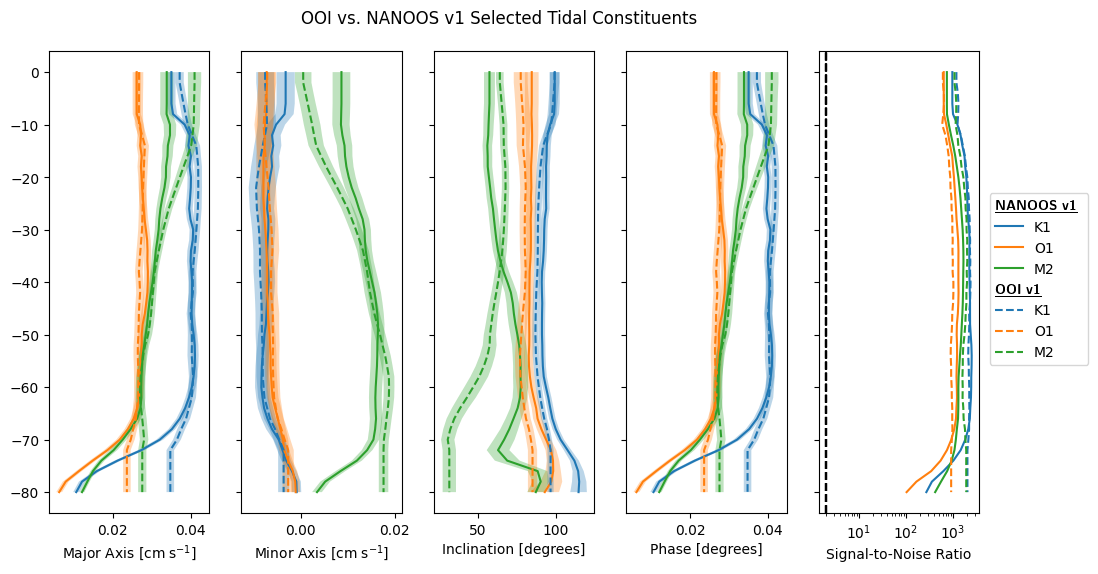

In [10]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)
constituents = ["K1", "O1", "M2"]
for const in constituents:
    tide = tide_v1_nanoos.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = tide_v1_ooi.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="--")
handles, labels = axs[0].get_legend_handles_labels()
proxy = mpatches.FancyBboxPatch(
    xy=(0, 0), width=0, height=0, visible=False, mutation_aspect=0
)
handles.append("NANOOS v1")
labels.append("")
handles.append("OOI v1")
labels.append("")
order = [6, 0, 1, 2, 7, 3, 4, 5]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
leg = fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)
fig.suptitle("OOI vs. NANOOS v1 Selected Tidal Constituents", fontsize=12, y=0.95)
plt.savefig(
    FIGURES_DIR / "ttide_velocity_nanoos_ooi_v1.png", dpi=300, bbox_inches="tight"
)

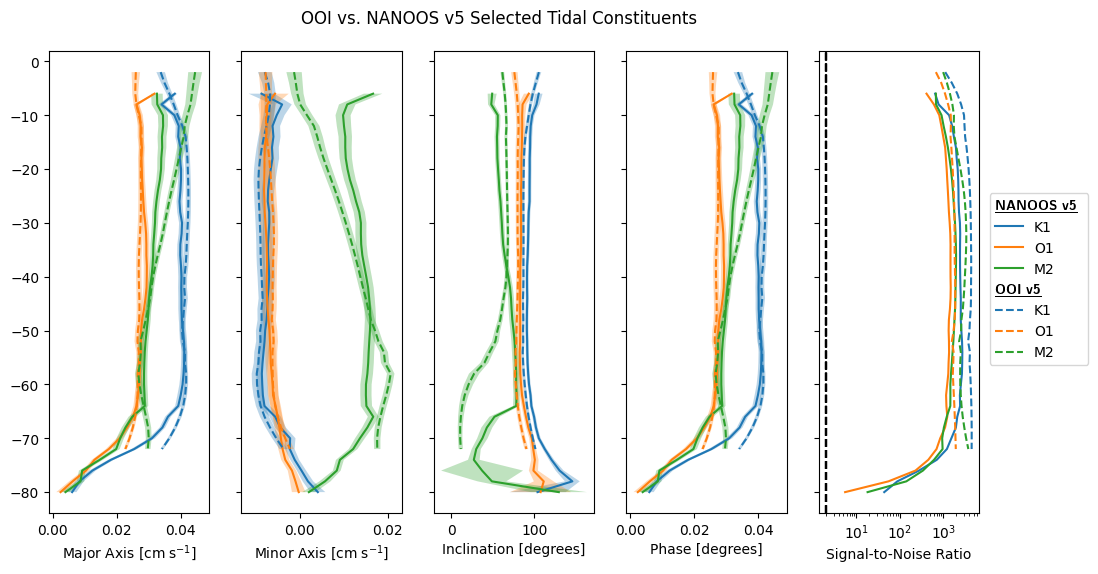

In [11]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)
constituents = ["K1", "O1", "M2"]
for const in constituents:
    tide = tide_v5_nanoos.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = tide_v5_ooi.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="--")
handles, labels = axs[0].get_legend_handles_labels()
proxy = mpatches.FancyBboxPatch(
    xy=(0, 0), width=0, height=0, visible=False, mutation_aspect=0
)
handles.append("NANOOS v5")
labels.append("")
handles.append("OOI v5")
labels.append("")
order = [6, 0, 1, 2, 7, 3, 4, 5]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
leg = fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)
fig.suptitle("OOI vs. NANOOS v5 Selected Tidal Constituents", fontsize=12, y=0.95)
plt.savefig(
    FIGURES_DIR / "ttide_velocity_nanoos_ooi_v5.png", dpi=300, bbox_inches="tight"
)

In [12]:
vel = velocity_v5.copy(deep=True)

In [13]:
velocity_v5.sel(time=OOI_TIME).u[-1] = np.full(
    velocity_v5.sel(time=OOI_TIME).u.shape[-1], 0.01
)  # set the last depth to value
velocity_v5.sel(time=OOI_TIME).v[-1] = np.full(
    velocity_v5.sel(time=OOI_TIME).v.shape[-1], 0
)  # set the last depth to value

In [14]:
vel_interp = vel.interpolate_na(dim="depth", method="cubic", max_gap=10)

ValueError: The number of derivatives at boundaries does not match: expected 2, got 0+0

In [ ]:
vel_interp_tide = fit_utide_from_ds(vel_interp)

Fitting UTide: 100%|██████████| 41/41 [02:06<00:00,  3.09s/it]


Text(0.5, 0.95, 'OOI vs. NANOOS v5 Selected Tidal Constituents')

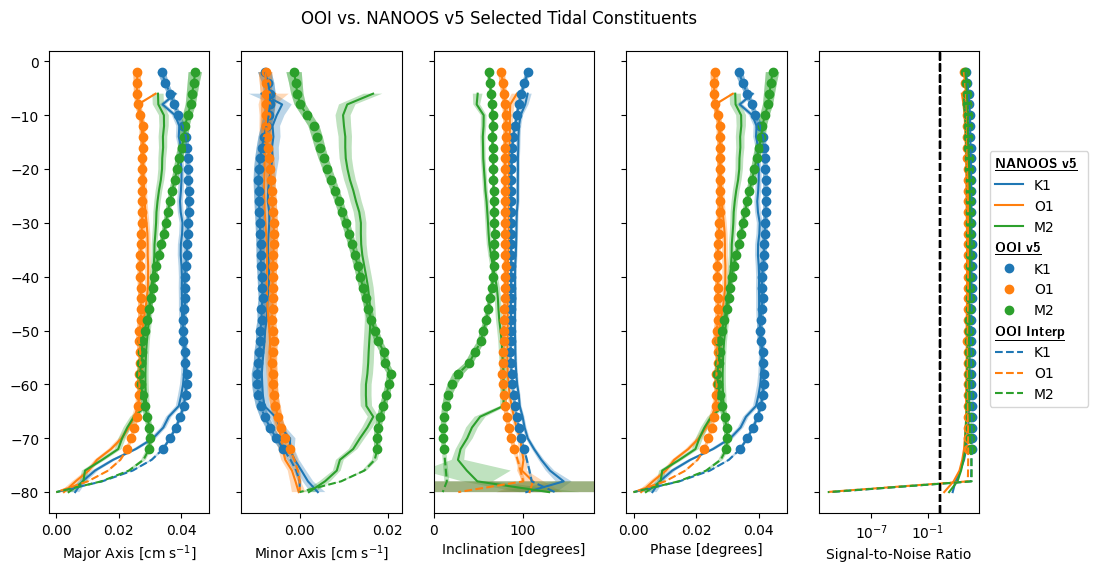

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)
constituents = ["K1", "O1", "M2"]
for const in constituents:
    tide = tide_v5_nanoos.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = tide_v5_ooi.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="", marker="o")
[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = vel_interp_tide.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="--")
axs[2].set_xlim(0, 180)
handles, labels = axs[0].get_legend_handles_labels()
proxy = mpatches.FancyBboxPatch(
    xy=(0, 0), width=0, height=0, visible=False, mutation_aspect=0
)
handles.append("NANOOS v5")
labels.append("")
handles.append("OOI v5")
labels.append("")
handles.append("OOI Interp")
labels.append("")
order = [9, 0, 1, 2, 10, 3, 4, 5, 11, 6, 7, 8]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
leg = fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)
fig.suptitle("OOI vs. NANOOS v5 Selected Tidal Constituents", fontsize=12, y=0.95)
# plt.savefig(
#     FIGURES_DIR / "ttide_velocity_nanoos_ooi_v5.png", dpi=300, bbox_inches="tight"
# )

In [ ]:
vel_ooi_interp = xr.open_dataset(
    DATA_DIR
    / "NH10_Mooring_Data/nh10_hourly_data_1997_2021_rotated_filtered_streamwise_interp_v5.nc",
)
vel_ooi_interp["u"] = vel_ooi_interp["u_interp"]
vel_ooi_interp["v"] = vel_ooi_interp["v_interp"]
vel_ooi_interp_tide = fit_utide_from_ds(vel_ooi_interp.sel(time=OOI_TIME))

Fitting UTide:   0%|          | 0/41 [00:00<?, ?it/s]

Fitting UTide:  98%|█████████▊| 40/41 [02:02<00:02,  2.20s/it]c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\utide\confidence.py:251: RuntimeWarning: invalid value encountered in scalar divide
  varXv = Pvv[c] * varXv / den
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\utide\confidence.py:252: RuntimeWarning: invalid value encountered in scalar divide
  varYv = Pvv[c] * varYv / den
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\utide\confidence.py:251: RuntimeWarning: divide by zero encountered in scalar divide
  varXv = Pvv[c] * varXv / den
c:\Users\asche\Desktop\po_code\shelf-nitrate-response-to-upwelling\.venv\Lib\site-packages\utide\confidence.py:252: RuntimeWarning: divide by zero encountered in scalar divide
  varYv = Pvv[c] * varYv / den
Fitting UTide: 100%|██████████| 41/41 [02:06<00:00,  3.08s/it]


Text(0.5, 0.95, 'OOI vs. NANOOS v5 Selected Tidal Constituents')

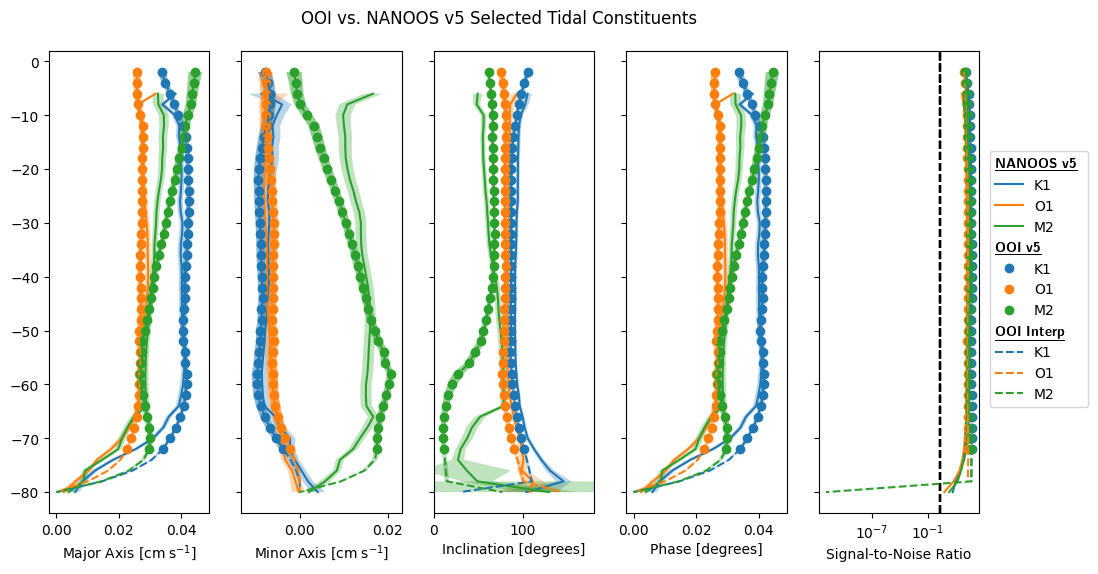

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(12, 6), sharey=True)
constituents = ["K1", "O1", "M2"]
for const in constituents:
    tide = tide_v5_nanoos.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig)

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = tide_v5_ooi.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="", marker="o")

[ax.set_prop_cycle(None) for ax in axs]  # reset color cycle for next plot
for const in constituents:
    tide = vel_ooi_interp_tide.sel(constituent=const)
    fig, axs = plot_tidal_constituents(tide, const, fig, ls="--")
axs[2].set_xlim(0, 180)
handles, labels = axs[0].get_legend_handles_labels()
proxy = mpatches.FancyBboxPatch(
    xy=(0, 0), width=0, height=0, visible=False, mutation_aspect=0
)
handles.append("NANOOS v5")
labels.append("")
handles.append("OOI v5")
labels.append("")
handles.append("OOI Interp")
labels.append("")
order = [9, 0, 1, 2, 10, 3, 4, 5, 11, 6, 7, 8]
handles = [handles[i] for i in order]
labels = [labels[i] for i in order]
leg = fig.legend(
    handles,
    labels,
    loc="center",
    bbox_to_anchor=(0.95, 0.5),
    handler_map={str: LegendTitle(text_props={"fontsize": 10}, width=55)},
)
fig.suptitle("OOI vs. NANOOS v5 Selected Tidal Constituents", fontsize=12, y=0.95)
# plt.savefig(
#     FIGURES_DIR / "ttide_velocity_nanoos_ooi_v5.png", dpi=300, bbox_inches="tight"
# )